In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib
# matplotlib.use('agg')
# matplotlib.use('TkAgg')

import matplotlib.pyplot as plt
import os
# from tqdm.notebook import  tqdm
from tqdm import  tqdm
import talib
import datetime

import  mplfinance as mpf

import sys
sys.path.append('../../DataSource/baostock')
import datasource

In [2]:
codes = datasource.getStockIndustry()
code = codes.at[0, 'code']
dt = datasource.getData(code)
dt.head()

,code,open,high,low,close,preclose,volume,amount,adjustflag,turn,tradestatus,pctChg,peTTM,pbMRQ,psTTM,pcfNcfTTM,isST
date,,,,,,,,,,,,,,,,,
2010-01-04,sh.600000,64.829140,64.947929,62.839423,62.928515,64.413379,66191338,1.419984e+09,1,0.835129,1,-2.3052,14.435065,2.877081,5.316299,7.091240,0
2010-01-05,sh.600000,63.581855,64.086709,61.740624,63.403671,62.928515,115147943,2.436891e+09,1,1.452808,1,0.7551,14.287342,2.898805,5.178308,7.144784,0
2010-01-06,sh.600000,63.225488,63.255185,62.007900,62.156386,63.403671,96782575,2.034174e+09,1,1.221095,1,-1.9672,14.006279,2.841779,5.076439,7.004231,0
2010-01-07,sh.600000,62.007900,62.483056,60.285458,60.760614,62.156386,85236072,1.761801e+09,1,1.075414,1,-2.2456,13.691757,2.777965,4.962444,6.846945,0
2010-01-08,sh.600000,60.404247,61.770322,60.285458,61.443652,60.760614,65707646,1.349532e+09,1,0.829026,1,1.1241,13.845672,2.809193,5.018229,6.923915,0


In [4]:
# 我想要计算N日内的最大值最小值，然后判断是否是横盘，然后判断是否超出的
BETWEEN_DAYS = 10 # 多少天的
BETWEEN_RANGE = 90 # 最低价是最高价的百分比
FUTURE_DAYS = 5 # 未来交易日的百分比
OVER_RANGE_MAX = 10 # 我这里设置最高超越

dt.loc[:, 'maxHigh'] = dt['high'].rolling(window=BETWEEN_DAYS).max() # 多日最高价
dt.loc[:, 'minLow'] = dt['low'].rolling(window=BETWEEN_DAYS).min()   # 多日的最低价
dt.loc[:, 'preMaxHigh'] = dt['maxHigh'].shift() # 往下移动
dt.loc[:, 'preMinLow'] = dt['minLow'].shift()   # 往下移动
dt.loc[:, 'overMaxHigh']= dt['close'] / dt['preMaxHigh'] *100 - 100 # 超过最高点的比例
dt.loc[:, 'underMinLow'] = dt['close'] / dt['preMinLow'] *100 - 100 # 低于最低点的比例
dt.loc[:, 'isRange'] = dt['preMaxHigh']/dt['preMinLow']*100 >= BETWEEN_RANGE  # 在横盘

for i in range(OVER_RANGE_MAX):
    dt.loc[:, f'isOverMaxHigh{i}'] = dt['close'] >= (dt['preMaxHigh'] * (100+i)/100) # 判断是否超越最高价的百分比
    dt.loc[:, f'isOverMinLow{i}'] = dt['close'] <= (dt['preMinLow'] * (100-i)/100)   # 判断是否低于最低价的百分比

# 先去掉na值
dt = dt.dropna()

for i in range(FUTURE_DAYS):
    # 这个是看未来多少天收盘价的幅度
    dt.loc[:, f'closePercent{i+1}'] = dt.loc[:, 'close'].shift(-(i+1))/dt['close']*100-100 # 这里是百分比幅度

# 然后转换类型
for i in range(FUTURE_DAYS):
    dt.loc[:, f'closePercent{i+1}'] = dt[f'closePercent{i+1}'].round()
    dt.loc[:, f'closePercent{i+1}'] = dt[f'closePercent{i+1}'].astype(int, errors='ignore')

# 这里实际上是收盘价创新高，忽略横盘影响。
dt2 = dt.loc[(dt[f'overMaxHigh'] > 0) & (dt['isRange'] == True), :]
dt3 = dt.loc[(dt[f'underMinLow'] < 0) & (dt['isRange'] == True), :]



In [5]:
print(len(dt2))
dt2.head()

293


,code,open,high,low,close,preclose,volume,amount,adjustflag,turn,...,isOverMinLow7,isOverMaxHigh8,isOverMinLow8,isOverMaxHigh9,isOverMinLow9,closePercent1,closePercent2,closePercent3,closePercent4,closePercent5
date,,,,,,,,,,,,,,,,,,,,,
2010-02-25,sh.600000,58.652108,61.770322,58.652108,61.592138,58.384833,194475975,3.998875e+09,1,2.453681,...,False,False,False,False,False,3.0,1.0,-0.0,2.0,4.0
2010-03-11,sh.600000,62.364267,64.740049,62.067294,63.255185,61.592138,230271759,4.943091e+09,1,2.905312,...,False,False,False,False,False,-1.0,-3.0,-1.0,2.0,2.0
2010-03-29,sh.600000,66.670371,68.660088,66.254609,68.244326,66.106123,139499328,3.200059e+09,1,1.760047,...,False,False,False,False,False,-1.0,-1.0,-0.0,0.0,-1.0
2010-06-21,sh.600000,54.473034,56.963230,53.889394,56.340681,54.083941,98921549,1.418075e+09,1,0.960063,...,False,False,False,False,False,0.0,-2.0,-1.0,-1.0,-0.0
2010-08-02,sh.600000,58.013781,59.531244,57.858144,59.531244,58.286146,65421012,9.920642e+08,1,0.634930,...,False,False,False,False,False,-3.0,-3.0,-5.0,-4.0,-5.0


In [6]:
print(len(dt3))
dt3.head()

309


,code,open,high,low,close,preclose,volume,amount,adjustflag,turn,...,isOverMinLow7,isOverMaxHigh8,isOverMinLow8,isOverMaxHigh9,isOverMinLow9,closePercent1,closePercent2,closePercent3,closePercent4,closePercent5
date,,,,,,,,,,,,,,,,,,,,,
2010-02-01,sh.600000,58.266044,58.266044,56.424813,57.078153,58.266044,51669420,9.943229e+08,1,0.651907,...,False,False,False,False,False,0.0,3.0,2.0,1.0,0.0
2010-04-16,sh.600000,67.323711,67.353408,65.393389,65.512178,67.620684,54964770,1.223885e+09,1,0.693484,...,False,False,False,False,False,-7.0,-7.0,-5.0,-8.0,-8.0
2010-04-19,sh.600000,64.413379,64.413379,60.849706,61.057587,65.512178,123269959,2.578443e+09,1,1.555283,...,False,False,False,False,False,-0.0,1.0,-2.0,-1.0,-0.0
2010-05-06,sh.600000,59.691513,59.691513,56.424813,56.543602,60.315155,74669511,1.455623e+09,1,0.942097,...,False,False,False,False,False,-3.0,-0.0,-2.0,1.0,4.0
2010-05-07,sh.600000,55.415106,56.662391,54.791463,55.088436,56.543602,61558279,1.154039e+09,1,0.776674,...,False,False,False,False,False,2.0,1.0,3.0,6.0,5.0


In [7]:

dt2.columns

Index(['code', 'open', 'high', 'low', 'close', 'preclose', 'volume', 'amount',
       'adjustflag', 'turn', 'tradestatus', 'pctChg', 'peTTM', 'pbMRQ',
       'psTTM', 'pcfNcfTTM', 'isST', 'maxHigh', 'minLow', 'preMaxHigh',
       'preMinLow', 'overMaxHigh', 'underMinLow', 'isRange', 'isOverMaxHigh0',
       'isOverMinLow0', 'isOverMaxHigh1', 'isOverMinLow1', 'isOverMaxHigh2',
       'isOverMinLow2', 'isOverMaxHigh3', 'isOverMinLow3', 'isOverMaxHigh4',
       'isOverMinLow4', 'isOverMaxHigh5', 'isOverMinLow5', 'isOverMaxHigh6',
       'isOverMinLow6', 'isOverMaxHigh7', 'isOverMinLow7', 'isOverMaxHigh8',
       'isOverMinLow8', 'isOverMaxHigh9', 'isOverMinLow9', 'closePercent1',
       'closePercent2', 'closePercent3', 'closePercent4', 'closePercent5'],
      dtype='object')

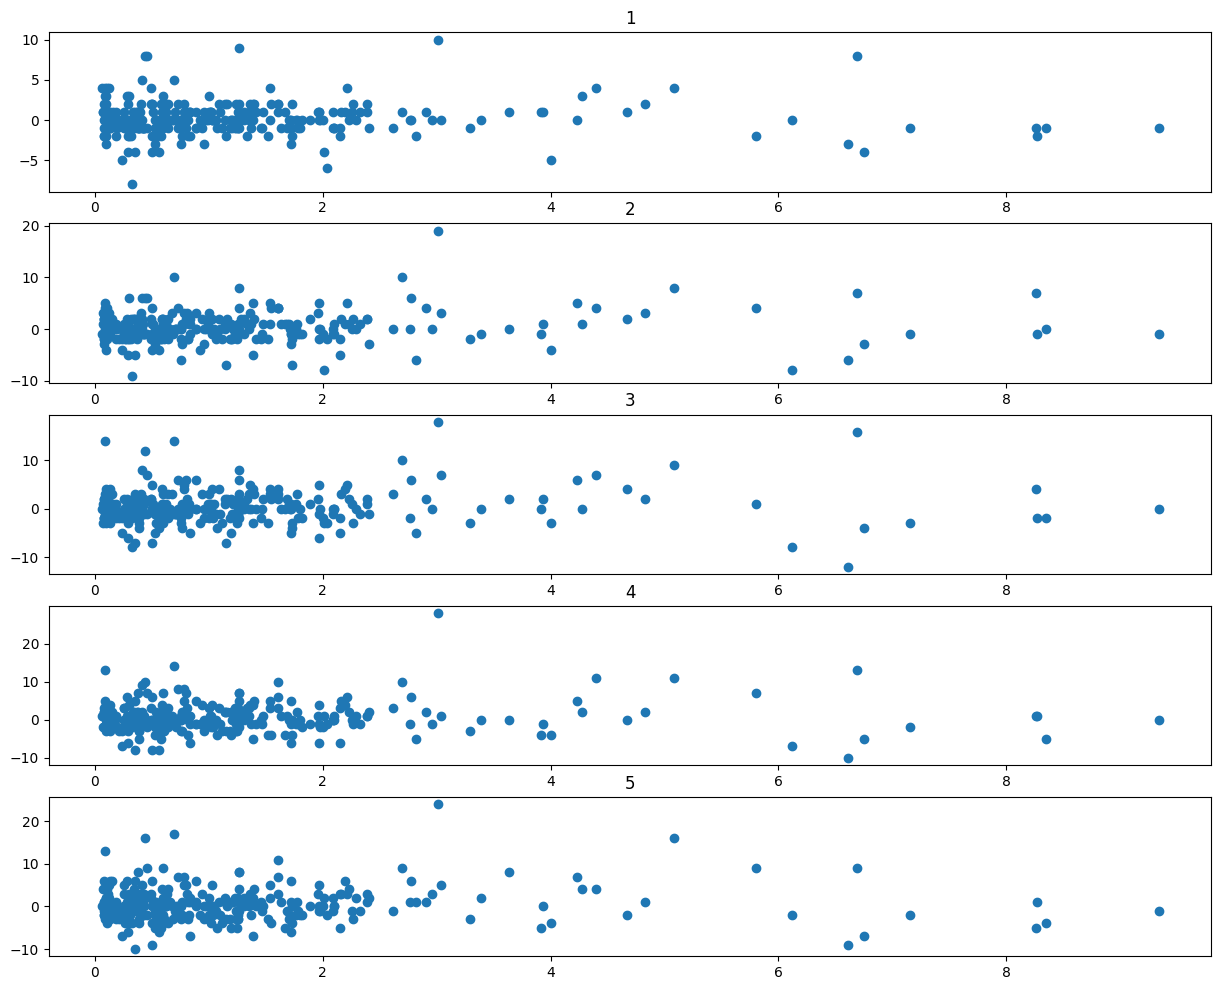

In [9]:
# 我这里想要看分布的图片，横轴是超过极值的百分比，纵轴是涨幅
plt.figure(figsize=(15, 12)) # 图片大小
for i in range(FUTURE_DAYS):
    plt.subplot(FUTURE_DAYS, 1, i+1)
    plt.scatter(dt2['overMaxHigh'], dt2[f'closePercent{i+1}'])
    plt.title(f'{i+1}')

In [11]:
# 这里看平均值的
for i in range(FUTURE_DAYS):
    _mean = dt2[f'closePercent{i+1}'].mean()
    _median = dt2[f'closePercent{i+1}'].median()
    print(f'{i+1}:平均值:{_mean}, 中位值:{_median}')

1:平均值:0.17064846416382254, 中位值:0.0
2:平均值:0.2832764505119454, 中位值:0.0
3:平均值:0.3447098976109215, 中位值:0.0
4:平均值:0.4880546075085324, 中位值:0.0
5:平均值:0.45733788395904434, 中位值:0.0


1:平均值:0.17064846416382254, 中位值:0.0
2:平均值:0.2832764505119454, 中位值:0.0
3:平均值:0.3447098976109215, 中位值:0.0
4:平均值:0.4880546075085324, 中位值:0.0
5:平均值:0.45733788395904434, 中位值:0.0


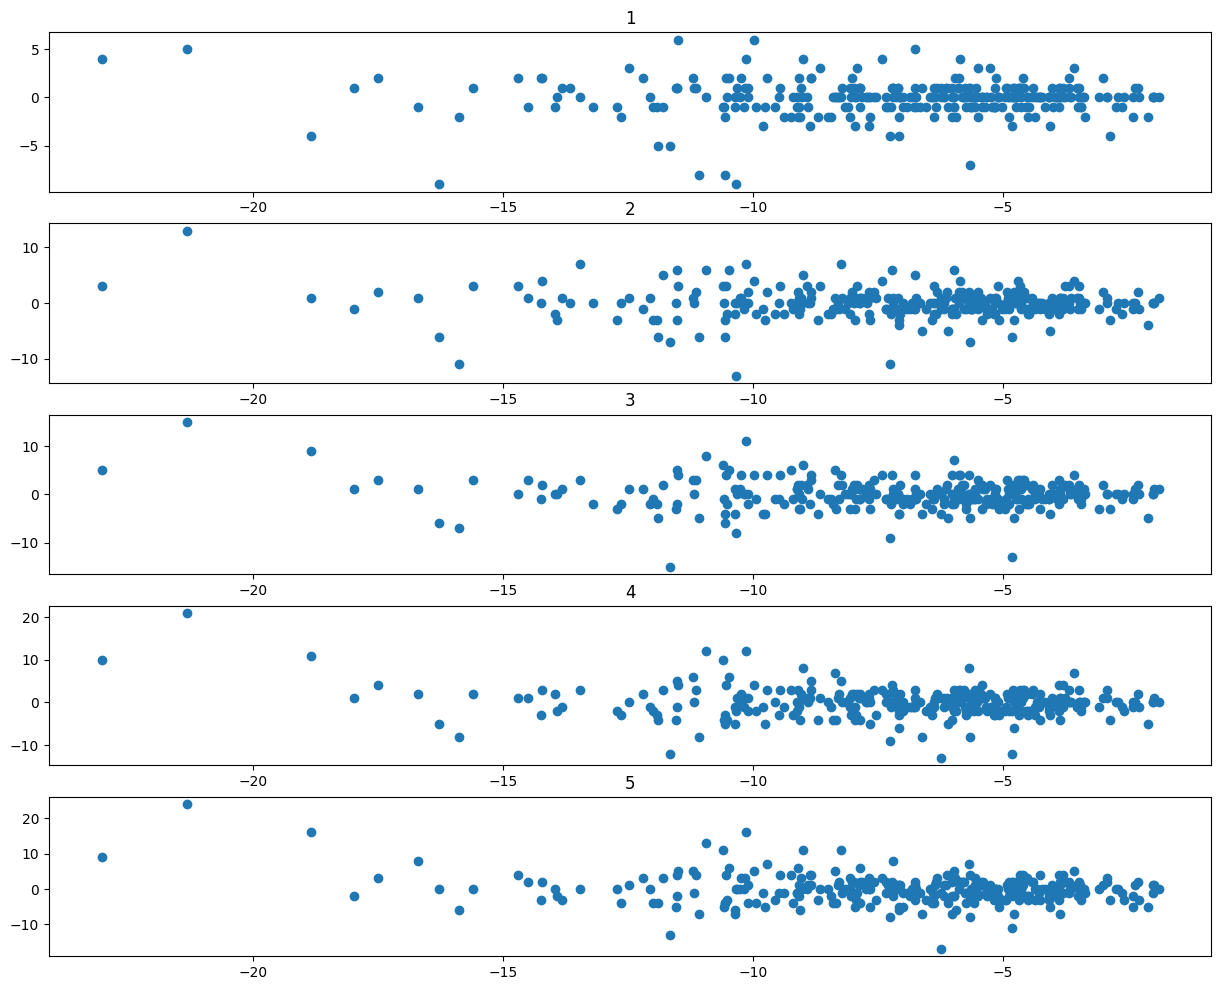

In [12]:
# 这里看下跌的
plt.figure(figsize=(15, 12)) # 图片大小
for i in range(FUTURE_DAYS):
    plt.subplot(FUTURE_DAYS, 1, i+1)
    plt.scatter(dt3['underMinLow'], dt3[f'closePercent{i+1}'])
    plt.title(f'{i+1}')
    _mean = dt2[f'closePercent{i+1}'].mean()
    _median = dt2[f'closePercent{i+1}'].median()
    print(f'{i+1}:平均值:{_mean}, 中位值:{_median}')
    

# 这里进行全部股票的统计

In [15]:
BETWEEN_DAYS = 10 # 多少天的
BETWEEN_RANGE = 90 # 最低价是最高价的百分比
FUTURE_DAYS = 5 # 未来交易日的百分比
OVER_RANGE_MAX = 10 # 我这里设置最高超越

dt_over_s = []  # 所有超过的
dt_under_s = [] # 所有低于的
for i in tqdm(range(len(codes))):
    code = codes.at[i, 'code']
    dt = datasource.get_data(code)
    dt.loc[:, 'maxHigh'] = dt['high'].rolling(window=BETWEEN_DAYS).max() # 多日最高价
    dt.loc[:, 'minLow'] = dt['low'].rolling(window=BETWEEN_DAYS).min()   # 多日的最低价
    dt.loc[:, 'preMaxHigh'] = dt['maxHigh'].shift() # 往下移动
    dt.loc[:, 'preMinLow'] = dt['minLow'].shift()   # 往下移动
    dt.loc[:, 'overMaxHigh']= dt['close'] / dt['preMaxHigh'] *100 - 100 # 超过最高点的比例
    dt.loc[:, 'underMinLow'] = dt['close'] / dt['preMinLow'] *100 - 100 # 低于最低点的比例
    dt.loc[:, 'isRange'] = dt['preMaxHigh']/dt['preMinLow']*100 >= BETWEEN_RANGE  # 在横盘
    # 百分比
    for j in range(OVER_RANGE_MAX):
        dt.loc[:, f'isOverMaxHigh{j}'] = dt['close'] >= (dt['preMaxHigh'] * (100+j)/100) # 判断是否超越最高价的百分比
        dt.loc[:, f'isOverMinLow{j}'] = dt['close'] <= (dt['preMinLow'] * (100-j)/100)   # 判断是否低于最低价的百分比
    # 先去掉na值
    dt = dt.dropna()
    #
    for j in range(FUTURE_DAYS):
        # 这个是看未来多少天收盘价的幅度
        dt.loc[:, f'closePercent{j+1}'] = dt.loc[:, 'close'].shift(-(j+1))/dt['close']*100-100 # 这里是百分比幅度
    # 然后转换类型
    for j in range(FUTURE_DAYS):
        dt.loc[:, f'closePercent{j+1}'] = dt[f'closePercent{j+1}'].round()
        dt.loc[:, f'closePercent{j+1}'] = dt[f'closePercent{j+1}'].astype(int, errors='ignore')
    
    # 这里实际上是收盘价创新高，
    dt2 = dt.loc[(dt[f'overMaxHigh'] > 0) & (dt['isRange'] == True), :]
    dt3 = dt.loc[(dt[f'underMinLow'] < 0) & (dt['isRange'] == True), :]
    # 然后添加进去
    if len(dt2) > 0:
        dt_over_s.append(dt2)
    if len(dt3) > 0:
        dt_under_s.append(dt3)


100%|██████████████████████████████████████████████████████████████████████████████| 5501/5501 [06:27<00:00, 14.18it/s]


In [18]:
dt2s = pd.concat(dt_over_s)
plt.figure(figsize=(15, 12)) # 图片大小
for i in range(FUTURE_DAYS):
    # plt.subplot(FUTURE_DAYS, 1, i+1)
    # plt.scatter(dt2s['overMaxHigh'], dt2s[f'closePercent{i+1}'])
    # plt.title(f'{i+1}')
    _mean = dt2s[f'closePercent{i+1}'].mean()
    _median = dt2s[f'closePercent{i+1}'].median()
    print(f'{i+1}:平均值:{_mean}, 中位值:{_median}')

C:\Users\xuhen\AppData\Local\Temp\ipykernel_27412\3200636796.py:1: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  dt2s = pd.concat(dt_over_s)
C:\Users\xuhen\AppData\Local\Temp\ipykernel_27412\3200636796.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  dt2s = pd.concat(dt_over_s)


1:平均值:0.2980116738956997, 中位值:0.0
2:平均值:0.4088394526231893, 中位值:0.0
3:平均值:0.468379545609333, 中位值:0.0
4:平均值:0.5162632329724401, 中位值:0.0
5:平均值:0.49895509409162314, 中位值:0.0


<Figure size 1500x1200 with 0 Axes>

In [20]:
dt3s = pd.concat(dt_under_s)
plt.figure(figsize=(15, 12)) # 图片大小
for i in range(FUTURE_DAYS):
    # plt.subplot(FUTURE_DAYS, 1, i+1)
    # plt.scatter(dt3s['underMinLow'], dt3s[f'closePercent{i+1}'])
    # plt.title(f'{i+1}')
    _mean = dt3s[f'closePercent{i+1}'].mean()
    _median = dt3s[f'closePercent{i+1}'].median()
    print(f'{i+1}:平均值:{_mean}, 中位值:{_median}')

C:\Users\xuhen\AppData\Local\Temp\ipykernel_27412\2201285072.py:1: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  dt3s = pd.concat(dt_under_s)
C:\Users\xuhen\AppData\Local\Temp\ipykernel_27412\2201285072.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  dt3s = pd.concat(dt_under_s)


1:平均值:-0.153118711546076, 中位值:0.0
2:平均值:-0.11419623291976302, 中位值:0.0
3:平均值:-0.022537422922212603, 中位值:0.0
4:平均值:0.10986434099760709, 中位值:0.0
5:平均值:0.28260733664508264, 中位值:0.0


<Figure size 1500x1200 with 0 Axes>